In [578]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [579]:


titanic = sns.load_dataset('titanic')

# تعمّد إضافة صفوف مكررة (زي ما بيصير بخطأ إدخال بيانات حقيقي)

duplicated_rows = titanic.sample(15, random_state=42)

messy_titanic = pd.concat([titanic, duplicated_rows], ignore_index=True)

# تعمّد خلط شكل النصوص ببعض القيم (Inconsistent Casing، زي ما بيصير لما ناس مختلفين يدخلوا بيانات)

messy_titanic.loc[messy_titanic.sample(20, random_state=1).index, 'embark_town'] = \
messy_titanic.loc[messy_titanic.sample(20, random_state=1).index, 'embark_town'].str.upper()

# جدول ثاني صغير لازم تدمجه مع messy_titanic

class_info = pd.DataFrame({'pclass': [1, 2, 3], 
                           'class_description': ['First Class - Luxury', 'Second Class - Standard', 'Third Class - Economy'],
                           'deck_access': ['Full Access', 'Limited Access', 'No Access']})

In [580]:
print(messy_titanic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     906 non-null    int64   
 1   pclass       906 non-null    int64   
 2   sex          906 non-null    object  
 3   age          726 non-null    float64 
 4   sibsp        906 non-null    int64   
 5   parch        906 non-null    int64   
 6   fare         906 non-null    float64 
 7   embarked     904 non-null    object  
 8   class        906 non-null    category
 9   who          906 non-null    object  
 10  adult_male   906 non-null    bool    
 11  deck         205 non-null    category
 12  embark_town  904 non-null    object  
 13  alive        906 non-null    object  
 14  alone        906 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 82.0+ KB
None


In [581]:
messy_titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,906.000000,906.000000,726.000000,906.000000,906.000000,906.000000
mean,0.385210,2.310155,29.614559,0.523179,0.380795,32.027966
std,0.486914,0.835567,14.486922,1.099479,0.803051,49.363078
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.000000,0.000000,0.000000,7.925000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [582]:
class_info

,pclass,class_description,deck_access
0,1,First Class - Luxury,Full Access
1,2,Second Class - Standard,Limited Access
2,3,Third Class - Economy,No Access


In [583]:
messy_titanic.duplicated()


0      False
1      False
2      False
3      False
4      False
       ...  
901     True
902     True
903     True
904     True
905     True
Length: 906, dtype: bool

In [584]:
messy_titanic['embark_town'].unique()
#اللي لاحظتو انو نان اعتبرها يونيك 
#و في اشماء مكررة بس احرف كابيتال

array(['Southampton', 'Cherbourg', 'Queenstown', 'SOUTHAMPTON',
       'CHERBOURG', nan, 'QUEENSTOWN'], dtype=object)

<Axes: xlabel='pclass', ylabel='count'>

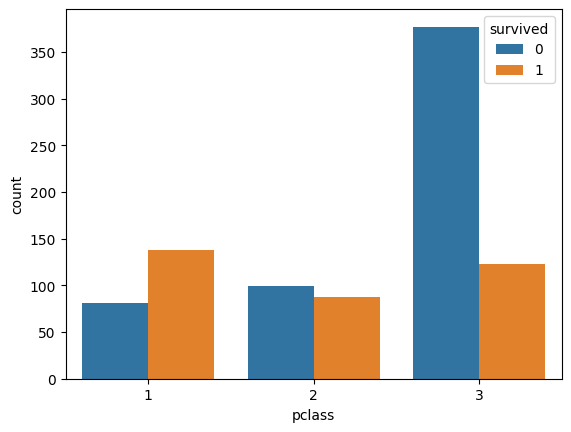

In [585]:
sns.countplot(data=messy_titanic, x= 'pclass', hue='survived')

<Axes: xlabel='pclass', ylabel='count'>

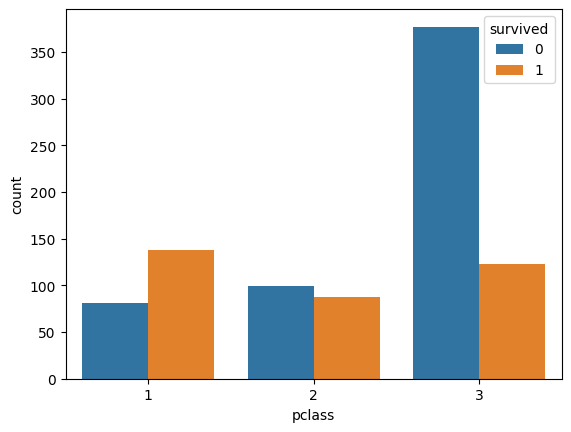

In [586]:
sns.countplot(data=messy_titanic, x= 'pclass', hue='survived')

<Axes: >

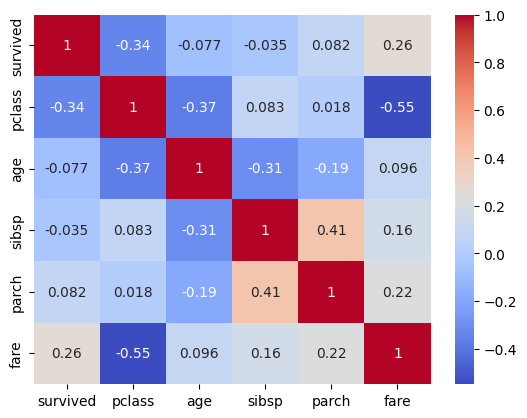

In [587]:
numeric_titanic = titanic.select_dtypes(include= ['number'])
sns.heatmap(numeric_titanic.corr(), annot=True, cmap='coolwarm')

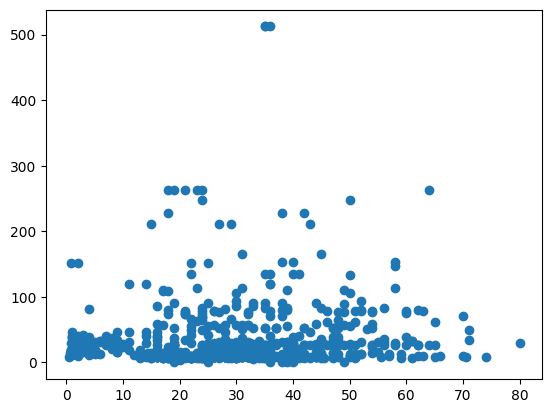

In [588]:
plt.scatter(messy_titanic['age'], messy_titanic['fare'])

<Axes: xlabel='age', ylabel='Count'>

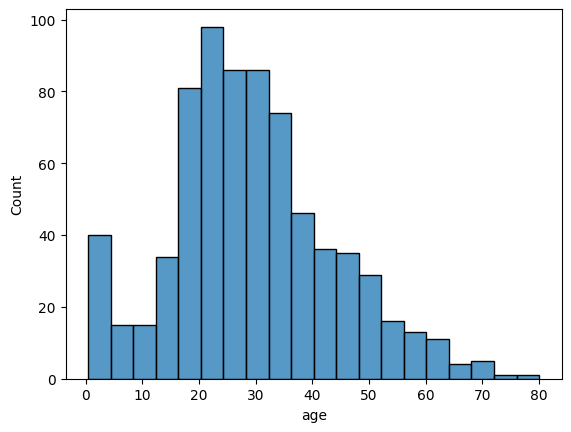

In [589]:
sns.histplot(messy_titanic['age'])

In [590]:
# اول اشي في اعمدة مكرر المقصود انو اعمدة باسماء مختلفة لاكن بتادي لنفس النتيجة 
#زي عامود سيرفايف و عامود الايف 
#تاني اشي في صفوف كمان صارت مكررة 
#في بعض القيم الفارغة 
#

In [591]:
messy_titanic['age'] = messy_titanic['age'].fillna(messy_titanic['age'].mean())

In [592]:
messy_titanic['embarked'] = messy_titanic['embarked'].fillna(messy_titanic['embarked'].mode()[0])

In [593]:
messy_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
901,0,1,male,37.000000,1,0,53.1000,S,First,man,True,C,Southampton,no,False
902,0,3,male,44.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
903,0,3,female,29.614559,3,1,25.4667,S,Third,woman,False,NaN,Southampton,no,False
904,0,3,male,30.000000,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True


In [594]:
messy_titanic = messy_titanic.drop(columns= ['deck', 'alive',])
#مسحتهم عشان هم عبارة عن اعمدة مكررة بس بئسم مختلف
#و الديك شلتها عشان الاغلبية فيها عبارة عن قيم فارغة

In [595]:
messy_titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
901,0,1,male,37.000000,1,0,53.1000,S,First,man,True,Southampton,False
902,0,3,male,44.000000,0,0,8.0500,S,Third,man,True,Southampton,True
903,0,3,female,29.614559,3,1,25.4667,S,Third,woman,False,Southampton,False
904,0,3,male,30.000000,0,0,7.2250,C,Third,man,True,Cherbourg,True


In [596]:
messy_titanic = messy_titanic.drop_duplicates().copy()

In [597]:
messy_titanic['embark_town'] = messy_titanic['embark_town'].str.title()
messy_titanic['embark_town'] = messy_titanic['embark_town'].fillna(messy_titanic['embark_town'].mode()[0])
messy_titanic['embark_town'].unique()


array(['Southampton', 'Cherbourg', 'Queenstown'], dtype=object)

In [598]:
messy_titanic.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64

In [599]:
merged_tc = pd.merge(messy_titanic, class_info, on='pclass',how= 'left')
print(merged_tc)

     survived  pclass     sex        age  sibsp  parch     fare embarked  \
0           0       3    male  22.000000      1      0   7.2500        S   
1           1       1  female  38.000000      1      0  71.2833        C   
2           1       3  female  26.000000      0      0   7.9250        S   
3           1       1  female  35.000000      1      0  53.1000        S   
4           0       3    male  35.000000      0      0   8.0500        S   
..        ...     ...     ...        ...    ...    ...      ...      ...   
777         0       3  female  39.000000      0      5  29.1250        Q   
778         1       1  female  19.000000      0      0  30.0000        S   
779         0       3  female  29.614559      1      2  23.4500        S   
780         1       1    male  26.000000      0      0  30.0000        C   
781         0       3    male  32.000000      0      0   7.7500        Q   

     class    who  adult_male  embark_town  alone      class_description  \
0    Third 

In [600]:
merged_tc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   survived           782 non-null    int64   
 1   pclass             782 non-null    int64   
 2   sex                782 non-null    object  
 3   age                782 non-null    float64 
 4   sibsp              782 non-null    int64   
 5   parch              782 non-null    int64   
 6   fare               782 non-null    float64 
 7   embarked           782 non-null    object  
 8   class              782 non-null    category
 9   who                782 non-null    object  
 10  adult_male         782 non-null    bool    
 11  embark_town        782 non-null    object  
 12  alone              782 non-null    bool    
 13  class_description  782 non-null    object  
 14  deck_access        782 non-null    object  
dtypes: bool(2), category(1), float64(2), int64(4), object(6)


In [601]:
merged_tc['sex'] = merged_tc['sex'].map({'male' : 0, 'female' : 1})
merged_tc = pd.get_dummies(merged_tc,columns=['who'])
merged_tc = pd.get_dummies(merged_tc, columns=['embarked'])
merged_tc = pd.get_dummies(merged_tc, columns=['embark_town'])
merged_tc = pd.get_dummies(merged_tc, columns= ['deck_access'])
merged_tc = pd.get_dummies(merged_tc, columns= ['class_description'])



In [602]:
merged_tc

,survived,pclass,sex,age,sibsp,parch,fare,class,adult_male,alone,...,embarked_S,embark_town_Cherbourg,embark_town_Queenstown,embark_town_Southampton,deck_access_Full Access,deck_access_Limited Access,deck_access_No Access,class_description_First Class - Luxury,class_description_Second Class - Standard,class_description_Third Class - Economy
0,0,3,0,22.000000,1,0,7.2500,Third,True,False,...,True,False,False,True,False,False,True,False,False,True
1,1,1,1,38.000000,1,0,71.2833,First,False,False,...,False,True,False,False,True,False,False,True,False,False
2,1,3,1,26.000000,0,0,7.9250,Third,False,True,...,True,False,False,True,False,False,True,False,False,True
3,1,1,1,35.000000,1,0,53.1000,First,False,False,...,True,False,False,True,True,False,False,True,False,False
4,0,3,0,35.000000,0,0,8.0500,Third,True,True,...,True,False,False,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,0,3,1,39.000000,0,5,29.1250,Third,False,False,...,False,False,True,False,False,False,True,False,False,True
778,1,1,1,19.000000,0,0,30.0000,First,False,True,...,True,False,False,True,True,False,False,True,False,False
779,0,3,1,29.614559,1,2,23.4500,Third,False,False,...,True,False,False,True,False,False,True,False,False,True
780,1,1,0,26.000000,0,0,30.0000,First,True,True,...,False,True,False,False,True,False,False,True,False,False


In [603]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
merged_tc[['age', 'fare']] = scaler.fit_transform(merged_tc[['age', 'fare']])

In [604]:
merged_tc['family_size'] = merged_tc['sibsp'] + merged_tc['parch'] + 1
merged_tc['age_group'] = pd.cut(merged_tc['age'] , bins= [0,12,19,59,100], labels=['Child', 'Teenager', 'Adult', 'old'])

merged_tc = pd.get_dummies(merged_tc, columns=['age_group'])

In [605]:
merged_tc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 30 columns):
 #   Column                                     Non-Null Count  Dtype   
---  ------                                     --------------  -----   
 0   survived                                   782 non-null    int64   
 1   pclass                                     782 non-null    int64   
 2   sex                                        782 non-null    int64   
 3   age                                        782 non-null    float64 
 4   sibsp                                      782 non-null    int64   
 5   parch                                      782 non-null    int64   
 6   fare                                       782 non-null    float64 
 7   class                                      782 non-null    category
 8   adult_male                                 782 non-null    bool    
 9   alone                                      782 non-null    bool    
 10  who_child     

In [607]:
merged_tc.to_csv('titanic_clean_ready.csv', index=False)